In [71]:
import torch.nn as tn
import pandas as pd


In [72]:
#impoprt the data
df = pd.read_excel('non_dim_final_formatted_data.xlsx')
df.head()


,0,Latitude,Longitude,(87Sr/86Sr)measured,(143Nd/144Nd)measured,(176Hf/177Hf)measured,(206Pb/204Pb)measured,(207Pb/204Pb)measured,(208Pb/204Pb)measured,Δ207Pb/204Pbb,...,Rb/Sr,Nb/Ta,K/Nb,K/U,Pb/Ce,Pb/Th,Hf/Sm,Ti/Gd,K/La,La/Sm
0,0,-1.521557,1.560189,0.149837,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,-1.549306,1.559974,0.376626,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,-1.549306,1.559974,-0.088922,0.033291,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,-1.549306,1.559974,0.691611,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,-1.549306,1.559974,0.187635,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [73]:
df = df.iloc[:, 1:]

df

,Latitude,Longitude,(87Sr/86Sr)measured,(143Nd/144Nd)measured,(176Hf/177Hf)measured,(206Pb/204Pb)measured,(207Pb/204Pb)measured,(208Pb/204Pb)measured,Δ207Pb/204Pbb,Δ208Pb/204Pbc,...,Rb/Sr,Nb/Ta,K/Nb,K/U,Pb/Ce,Pb/Th,Hf/Sm,Ti/Gd,K/La,La/Sm
0,-1.521557,1.560189,0.149837,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-1.549306,1.559974,0.376626,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-1.549306,1.559974,-0.088922,0.033291,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-1.549306,1.559974,0.691611,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-1.549306,1.559974,0.187635,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13016,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13017,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13018,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13019,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [74]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)#to split data into 80/20 training/testing


In [75]:
train_df.head()

,Latitude,Longitude,(87Sr/86Sr)measured,(143Nd/144Nd)measured,(176Hf/177Hf)measured,(206Pb/204Pb)measured,(207Pb/204Pb)measured,(208Pb/204Pb)measured,Δ207Pb/204Pbb,Δ208Pb/204Pbc,...,Rb/Sr,Nb/Ta,K/Nb,K/U,Pb/Ce,Pb/Th,Hf/Sm,Ti/Gd,K/La,La/Sm
5180,0.295573,-1.093588,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
11890,-0.782010,-1.269286,1.064553,-1.843270,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.059951,0.40111,-0.164515,-0.108336,0.0,0.0,-0.441062,0.945534,-0.242395,0.860117
9278,1.636148,0.463853,-0.348470,0.512557,0.000000,0.506349,0.007146,0.172602,0.020403,-0.076321,...,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
6605,0.270401,-1.094155,-0.018995,-0.297469,0.204314,-1.065688,-1.103811,-1.199309,0.053975,0.098968,...,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
3656,-0.358610,-0.348275,-0.449265,0.856818,0.314312,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000


In [76]:
str= ''
for col_name in train_df.columns.tolist():
    str+= ''.join(col_name)
    str += ', '
print(str)

Latitude , Longitude , (87Sr/86Sr)measured, (143Nd/144Nd)measured, (176Hf/177Hf)measured, (206Pb/204Pb)measured, (207Pb/204Pb)measured, (208Pb/204Pb)measured, Δ207Pb/204Pbb, Δ208Pb/204Pbc, (206Pb/204Pb)measured.1, (207Pb/204Pb)measured.1, (208Pb/204Pb)measured.1, δ18Oglass, δ18Oolivine, δ18Oclinopyroxene, δ18Oplagioclase, Calculated δ18O of olivine in equilibrium with glassd, Calculated δ18O of olivine in equilibrium with clinopyroxenee, Calculated δ18O of olivine in equilibrium with plagioclasef, (187Os/188Os)measured-whole rock, [Os]whole rock (ppt), (187Os/188Os)measured-olivine, [Os]olivine (ppt), (187Os/188Os)measured-clinopyroxene , [Os]clinopyroxene (ppt), R/RA, R/RA.1, [4He] (i.e., 10-9 cm3STP/gcrush), [4He] (i.e., 10-9 cm3STP/gfusion), He phase, SiO2 (wt.%), TiO2 (wt.%), Al2O3 (wt.%), FeOT (wt.%), MnO (wt.%), MgO (wt.%), CaO (wt.%), Na2O (wt.%), K2O (wt.%), P2O5 (wt.%), Total (wt.%), Major phase, Method, CaO/Al2O3, LOI (wt.%), Alkali indexg, Li (ppm), Be (ppm), B (ppm), P (ppm

In [77]:
test_df['Latitude '].head()


811      0.825537
10379   -1.125403
353      0.854901
3409    -0.388718
4901     0.254912
Name: Latitude , dtype: float64

In [78]:
import re
#this whole cell is just to format the names properly into the column names using regex just count this as a debug step
text = 'Latitude ,Longitude ,(87Sr/86Sr)measured,(143Nd/144Nd)measured,(176Hf/177Hf)measured,(206Pb/204Pb)measured,(207Pb/204Pb)measured,(208Pb/204Pb)measured,Δ207Pb/204Pbb,Δ208Pb/204Pbc,(206Pb/204Pb)measured.1,(207Pb/204Pb)measured.1,(208Pb/204Pb)measured.1,δ18Oglass,δ18Oolivine,δ18Oclinopyroxene,δ18Oplagioclase,Calculated δ18O of olivine in equilibrium with glassd,Calculated δ18O of olivine in equilibrium with clinopyroxenee,Calculated δ18O of olivine in equilibrium with plagioclasef,(187Os/188Os)measured-whole rock,[Os]whole rock (ppt),(187Os/188Os)measured-olivine,[Os]olivine (ppt),(187Os/188Os)measured-clinopyroxene ,[Os]clinopyroxene (ppt),R/RA,R/RA.1,[4He] (i.e., 10-9 cm3STP/gcrush),[4He] (i.e., 10-9 cm3STP/gfusion),He phase,SiO2 (wt.%),TiO2 (wt.%),Al2O3 (wt.%),FeOT (wt.%),MnO (wt.%),MgO (wt.%),CaO (wt.%),Na2O (wt.%),K2O (wt.%),P2O5 (wt.%),Total (wt.%),Major phase,Method,CaO/Al2O3,LOI (wt.%),Alkali indexg,Li (ppm),Be (ppm),B (ppm),P (ppm),K (ppm),Sc (ppm),Ti (ppm),V (ppm),Cr (ppm),Mn (ppm),Co (ppm),Ni (ppm),Cu (ppm),Zn (ppm),Ga (ppm),Ge (ppm),As (ppm),Se (ppm),Rb (ppm),Sr (ppm),Y (ppm),Zr (ppm),Nb (ppm),Mo (ppm),Cd (ppm),In (ppm),Sn (ppm),Sb (ppm),Te (ppm),Cs (ppm),Ba (ppm),La (ppm),Ce (ppm),Pr (ppm),Nd (ppm),Sm (ppm),Eu (ppm),Gd (ppm),Tb (ppm),Dy (ppm),Ho (ppm),Er (ppm),Tm (ppm),Yb (ppm),Lu (ppm),Hf (ppm),Ta (ppm),W (ppm),Tl (ppm),Pb (ppm),Bi (ppm),Th (ppm),U (ppm),Ba/Rb,Th/U,Y/Y*h,Ce/Ce*i,K2O/P2O5,Nb/Th,Rb/Th,Zr/Zr*j,Eu/Eu*k,Sr/Sr*l,Ba/Th,Ba/Nb,Rb/Sr,Nb/Ta,K/Nb,K/U,Pb/Ce,Pb/Th,Hf/Sm,Ti/Gd,K/La,La/Sm,'
pattern = r'\s*([^,]+?)\s*(,|$)'

result = re.sub(pattern, r"'\1'\2", text)

print(result)


'Latitude','Longitude','(87Sr/86Sr)measured','(143Nd/144Nd)measured','(176Hf/177Hf)measured','(206Pb/204Pb)measured','(207Pb/204Pb)measured','(208Pb/204Pb)measured','Δ207Pb/204Pbb','Δ208Pb/204Pbc','(206Pb/204Pb)measured.1','(207Pb/204Pb)measured.1','(208Pb/204Pb)measured.1','δ18Oglass','δ18Oolivine','δ18Oclinopyroxene','δ18Oplagioclase','Calculated δ18O of olivine in equilibrium with glassd','Calculated δ18O of olivine in equilibrium with clinopyroxenee','Calculated δ18O of olivine in equilibrium with plagioclasef','(187Os/188Os)measured-whole rock','[Os]whole rock (ppt)','(187Os/188Os)measured-olivine','[Os]olivine (ppt)','(187Os/188Os)measured-clinopyroxene','[Os]clinopyroxene (ppt)','R/RA','R/RA.1','[4He] (i.e.','10-9 cm3STP/gcrush)','[4He] (i.e.','10-9 cm3STP/gfusion)','He phase','SiO2 (wt.%)','TiO2 (wt.%)','Al2O3 (wt.%)','FeOT (wt.%)','MnO (wt.%)','MgO (wt.%)','CaO (wt.%)','Na2O (wt.%)','K2O (wt.%)','P2O5 (wt.%)','Total (wt.%)','Major phase','Method','CaO/Al2O3','LOI (wt.%)','Alka

In [79]:
import ast
columns =  ast.literal_eval(result)
columns

('Latitude',
 'Longitude',
 '(87Sr/86Sr)measured',
 '(143Nd/144Nd)measured',
 '(176Hf/177Hf)measured',
 '(206Pb/204Pb)measured',
 '(207Pb/204Pb)measured',
 '(208Pb/204Pb)measured',
 'Δ207Pb/204Pbb',
 'Δ208Pb/204Pbc',
 '(206Pb/204Pb)measured.1',
 '(207Pb/204Pb)measured.1',
 '(208Pb/204Pb)measured.1',
 'δ18Oglass',
 'δ18Oolivine',
 'δ18Oclinopyroxene',
 'δ18Oplagioclase',
 'Calculated δ18O of olivine in equilibrium with glassd',
 'Calculated δ18O of olivine in equilibrium with clinopyroxenee',
 'Calculated δ18O of olivine in equilibrium with plagioclasef',
 '(187Os/188Os)measured-whole rock',
 '[Os]whole rock (ppt)',
 '(187Os/188Os)measured-olivine',
 '[Os]olivine (ppt)',
 '(187Os/188Os)measured-clinopyroxene',
 '[Os]clinopyroxene (ppt)',
 'R/RA',
 'R/RA.1',
 '[4He] (i.e.',
 '10-9 cm3STP/gcrush)',
 '[4He] (i.e.',
 '10-9 cm3STP/gfusion)',
 'He phase',
 'SiO2 (wt.%)',
 'TiO2 (wt.%)',
 'Al2O3 (wt.%)',
 'FeOT (wt.%)',
 'MnO (wt.%)',
 'MgO (wt.%)',
 'CaO (wt.%)',
 'Na2O (wt.%)',
 'K2O (wt.%)'

In [80]:
#fixing what the regex messed up i cant stand regex lowk
columns_list = list(columns)
columns_list[0]='Latitude '
columns_list[1] = 'Longitude '
columns_list[24] = '(187Os/188Os)measured-clinopyroxene '
columns_list[28] = '[4He] (i.e., 10-9 cm3STP/gcrush)'
columns_list[30] = '[4He] (i.e., 10-9 cm3STP/gfusion)'
del columns_list[29] 
del columns_list[31]
columns = tuple(columns_list)

In [81]:
columns

('Latitude ',
 'Longitude ',
 '(87Sr/86Sr)measured',
 '(143Nd/144Nd)measured',
 '(176Hf/177Hf)measured',
 '(206Pb/204Pb)measured',
 '(207Pb/204Pb)measured',
 '(208Pb/204Pb)measured',
 'Δ207Pb/204Pbb',
 'Δ208Pb/204Pbc',
 '(206Pb/204Pb)measured.1',
 '(207Pb/204Pb)measured.1',
 '(208Pb/204Pb)measured.1',
 'δ18Oglass',
 'δ18Oolivine',
 'δ18Oclinopyroxene',
 'δ18Oplagioclase',
 'Calculated δ18O of olivine in equilibrium with glassd',
 'Calculated δ18O of olivine in equilibrium with clinopyroxenee',
 'Calculated δ18O of olivine in equilibrium with plagioclasef',
 '(187Os/188Os)measured-whole rock',
 '[Os]whole rock (ppt)',
 '(187Os/188Os)measured-olivine',
 '[Os]olivine (ppt)',
 '(187Os/188Os)measured-clinopyroxene ',
 '[Os]clinopyroxene (ppt)',
 'R/RA',
 'R/RA.1',
 '[4He] (i.e., 10-9 cm3STP/gcrush)',
 '[4He] (i.e., 10-9 cm3STP/gfusion)',
 '10-9 cm3STP/gfusion)',
 'SiO2 (wt.%)',
 'TiO2 (wt.%)',
 'Al2O3 (wt.%)',
 'FeOT (wt.%)',
 'MnO (wt.%)',
 'MgO (wt.%)',
 'CaO (wt.%)',
 'Na2O (wt.%)',
 'K2

In [82]:
import numpy as np
import pandas as pd
import torch

import numpy as np
import pandas as pd
import torch

def prepare_dataframe_by_column(df, numerical_cols, mask_probability=0.15):

    collected_columns = []
    
    for col in numerical_cols: #iterate through each column name individualy
        if col in df.columns:
            col_tensor = torch.tensor(df[col].values, dtype=torch.float32) #cnvert to tensor
            collected_columns.append(col_tensor.unsqueeze(1))#add dim to resize it accordingly later
        else:
            print(f"Warning: Column '{col}' not found , skippinh to next one")
            
    if len(collected_columns) == 0:
        raise ValueError("none of these columns are in the dataframe")
        
    ground_truth = torch.cat(collected_columns, dim=1)#make the columns line up again
    real_data_mask = (ground_truth != 0.0) #where real data is, not 0.0
    random_matrix = torch.rand(ground_truth.shape) < mask_probability #makes random matirx for masking
    synthetic_zero_mask = real_data_mask & random_matrix #these are just the synthetic zero for the mask
    
    input_data = ground_truth.clone() #makes a copy to form synthetic data
    input_data[synthetic_zero_mask] = 0.0
    
    return input_data, synthetic_zero_mask, ground_truth

#call method
updated_data_train = prepare_dataframe_by_column(train_df,columns)


In [83]:
updated_data_train

(tensor([[ 0.0000, -1.0936,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [-0.7820, -1.2693,  0.0000,  ...,  0.9455, -0.2424,  0.8601],
         [ 1.6361,  0.4639,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         ...,
         [ 0.2571, -1.0861,  0.0062,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000, -0.2974,  ...,  0.0000,  0.0000,  0.0000],
         [-1.8778,  1.4664,  1.0066,  ...,  0.0000,  0.0000,  0.0000]]),
 tensor([[ True, False, False,  ..., False, False, False],
         [False, False,  True,  ..., False, False, False],
         [False, False,  True,  ..., False, False, False],
         ...,
         [False, False, False,  ..., False, False,  True],
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False]]),
 tensor([[ 0.2956, -1.0936,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [-0.7820, -1.2693,  1.0646,  ...,  0.9455, -0.2424,  0.8601],
         [ 1.6361,  0.4639, -0.3485,  ...,  0.

In [84]:
# need to do itf:
#training script with:
#scheduling using pytorch


In [85]:
import torch

In [86]:
enc_layer = tn.TransformerEncoderLayer(d_model = 122, nhead=2)
model = tn.TransformerEncoder(enc_layer, num_layers=4)
#make input tensor from train_df
input_tensor = torch.tensor(train_df.values, dtype = torch.float32)
actual_input = input_tensor.to(torch.float32)
out = model(actual_input)

C:\Users\afsee\AppData\Local\Temp\ipykernel_7484\4240183481.py:2: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  model = tn.TransformerEncoder(enc_layer, num_layers=4)


In [87]:
out.shape

torch.Size([10416, 122])

In [88]:
#optimizer
#training loop
#loss function
#gradient

In [89]:
#optimizer stage:
from torch import optim
from torch.optim import AdamW
#i'm using AdamW so that the decay does not accumulate
optimizer = optim.AdamW(model.parameters())

In [162]:
import torch
from torch.nn import GaussianNLLLoss
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, AutoModelForMaskedLM
import torch
import torch.nn as nn
import matplotlib.pyplot as plt 
import numpy as np

#make a class to process the already tensorfied training data from earlier
class PreTensorfiedDataset(Dataset):
    def __init__(self, input_data, mask, ground_truth): #function to intiialize the 3 fields input data, mask aka 15% blocked values, ground truth aka right answers
        self.input_data = input_data
        self.mask = mask.float()  #changes true false missing spots filled in spots to deciaml 1.0 and 0.0
        self.ground_truth = ground_truth

    def __len__(self): #returns size of dataset
        return len(self.input_data)

    def __getitem__(self, idx): #gets iten at a specified location
        return self.input_data[idx], self.ground_truth[idx], self.mask[idx]


input_tensors, mask_tensors, target_tensors = updated_data_train #stores the output arrays from preprocessing function
dataset = PreTensorfiedDataset(input_tensors, mask_tensors, target_tensors) #sends them into class above^^
train_loader = DataLoader(dataset, batch_size=64, shuffle=True) #pytorch iterator


num_element_chemicals = input_tensors.size(1) 


class TransformerModel(nn.Module): #new neural network class from nn.Module
    def __init__(self, input_dim): #initializes instance
        super().__init__()
        self.input_layer = nn.Linear(input_dim, 64) #scales up data to 64 dimention
        
        #sets model from a couple code blocks earlier
        encoder_layer = nn.TransformerEncoderLayer(d_model=64, nhead=4, batch_first=True, dropout=0.0, dim_feedforward=64)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        
        #two different output head bc this si needed for gaussian nll 
        self.mean_head = nn.Linear(64, input_dim)
        self.variance_head = nn.Linear(64, input_dim)

    def forward(self, x): #sends data the right direction
        x = x.unsqueeze(1) #tabular data has no data but this needs word length so set all to 1
        h = self.input_layer(x)
        h = self.transformer(h)#saves the learned features into hidden var h
        h = h.squeeze(1) #gets rid of the extra length dimension from earlier
        #passes features through the 2 exit heads
        mean = self.mean_head(h)
        variance = torch.exp(self.variance_head(h)) + 1e-6 
        return mean, variance #returns them
    
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") #just in case if i have cuda
model = TransformerModel(input_dim=num_element_chemicals).to(device) #send the computations to computer cpu
optimizer = torch.optim.AdamW(model.parameters(), lr=0.00001) #adamW optimizer

nparam = sum(p.numel() for p in model.parameters() if p.requires_grad)
nparam


73970

In [163]:
#making test_loader:

updated_data_test = prepare_dataframe_by_column(test_df,columns)
input_tensors_test, mask_tensors_test, target_tensors_test = updated_data_test #stores the output arrays from preprocessing function
dataset_test = PreTensorfiedDataset(input_tensors_test, mask_tensors_test, target_tensors_test) #sends them into class above^^
test_loader = DataLoader(dataset_test, batch_size=16, shuffle=False) #pytorch iterator

In [164]:
def validation_phase(model, test_loader, criterion_loss_func, device):
    model.eval()
    run_loss = 0.0
    with torch.no_grad():
            for features, targets, missing_indicators in test_loader:
                features = features.to(device)
                targets = targets.to(device)
                missing_indicators = missing_indicators.to(device)
                predicted_means, predicted_vars = model(features) #saves the model results fro  feedign in model the validation data
                raw_loss = criterion(predicted_means, targets,  torch.ones_like(predicted_means)) #saves loss into a var
                masked_loss = raw_loss * missing_indicators #incorporates the mask
                loss = masked_loss.sum() / (missing_indicators.sum() + 1e-8)
                run_loss += loss.item()
            test_loss = run_loss /len(test_loader)
            return test_loss

In [165]:

#loss function is gaussian nll 
criterion = nn.GaussianNLLLoss(reduction='none') 
loss_func_test = nn.NLLLoss()

epochs = 20


loss_history = []
loss_history_test = []
for epoch in range(epochs):
    model.train()
    run_loss = 0.0
    for features, targets, missing_indicators in train_loader: #saves each of these vars per iteration
        features = features.to(device)
        targets = targets.to(device)
        missing_indicators = missing_indicators.to(device)
        optimizer.zero_grad(set_to_none=True)
        predicted_means, predicted_vars = model(features)
        #raw_loss = criterion(predicted_means, targets, predicted_vars) #saves loss into a var
        raw_loss = criterion(predicted_means, targets, torch.ones_like(predicted_means)) #saves loss into a var
        masked_loss = raw_loss * missing_indicators #incorporates the mask
        loss = masked_loss.sum() / (missing_indicators.sum() + 1e-8)
        loss.backward() #goes back on loss to see how much each weight contributed 
        optimizer.step() #updates these weights based on the loss function
        run_loss += loss.item()
    epoch_loss = run_loss /len(train_loader)
    loss_history.append(epoch_loss)
    print(f"TRAIN Epoch {epoch+1:02d}/{epochs}-GaussianNLLLoss: {epoch_loss:.4f}")
    
    epoch_loss_test = validation_phase(model, test_loader, loss_func_test, device)
    loss_history_test.append(epoch_loss_test)
    print(f"TEST Epoch {epoch+1:02d}/{epochs}-NLLoss: {epoch_loss_test:.4f}")
    
#save model
save_weights_path = 'model_weights.pth'
torch.save(model.state_dict(), save_weights_path)

TRAIN Epoch 01/20-GaussianNLLLoss: 0.6707
TEST Epoch 01/20-NLLoss: 0.5823
TRAIN Epoch 02/20-GaussianNLLLoss: 0.6421
TEST Epoch 02/20-NLLoss: 0.5534
TRAIN Epoch 03/20-GaussianNLLLoss: 0.6172
TEST Epoch 03/20-NLLoss: 0.5281
TRAIN Epoch 04/20-GaussianNLLLoss: 0.5884
TEST Epoch 04/20-NLLoss: 0.5059
TRAIN Epoch 05/20-GaussianNLLLoss: 0.5682
TEST Epoch 05/20-NLLoss: 0.4862
TRAIN Epoch 06/20-GaussianNLLLoss: 0.5437
TEST Epoch 06/20-NLLoss: 0.4688
TRAIN Epoch 07/20-GaussianNLLLoss: 0.5321
TEST Epoch 07/20-NLLoss: 0.4533
TRAIN Epoch 08/20-GaussianNLLLoss: 0.5180
TEST Epoch 08/20-NLLoss: 0.4395
TRAIN Epoch 09/20-GaussianNLLLoss: 0.5031
TEST Epoch 09/20-NLLoss: 0.4272
TRAIN Epoch 10/20-GaussianNLLLoss: 0.4859
TEST Epoch 10/20-NLLoss: 0.4162
TRAIN Epoch 11/20-GaussianNLLLoss: 0.4796
TEST Epoch 11/20-NLLoss: 0.4063
TRAIN Epoch 12/20-GaussianNLLLoss: 0.4652
TEST Epoch 12/20-NLLoss: 0.3974
TRAIN Epoch 13/20-GaussianNLLLoss: 0.4607
TEST Epoch 13/20-NLLoss: 0.3894
TRAIN Epoch 14/20-GaussianNLLLoss: 0.4

In [ ]:
#initialization scheme

C:\Users\afsee\AppData\Local\Temp\ipykernel_7484\4284813796.py:3: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-" (-> color='b'). The keyword argument will take precedence.
  ax.plot(range(1, epochs + 1), loss_history_test, 'b-', marker='o', color = 'red', label = 'test')


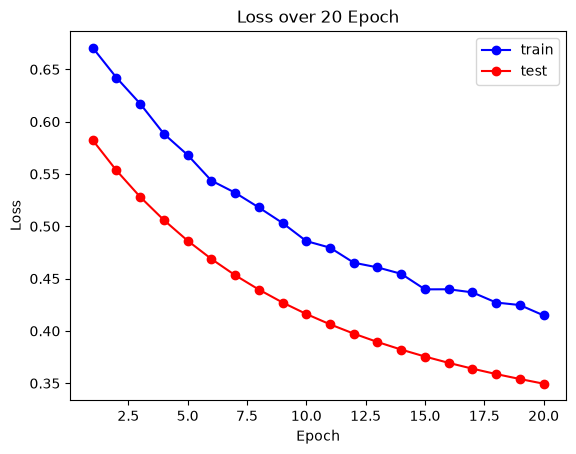

In [166]:
fig, ax = plt.subplots()
ax.plot(range(1, epochs + 1), loss_history, 'b-', marker='o', label = 'train')
ax.plot(range(1, epochs + 1), loss_history_test, 'b-', marker='o', color = 'red', label = 'test')
ax.set_title('Loss over 20 Epoch')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend(loc= 'upper right')
plt.show()


In [ ]:
#reverse check if the filled in data makes sense or not
predicted_means #model results, get the missing vals filled in here to compare against to see if theyre correct or not
predicted_vars
targets #known and blocked data so get missing vals from here to compare against

In [46]:
missing_vals = (missing_indicators==1.0)
actual_missing_vals = targets[missing_vals]
model_guess_missing_vals = predicted_means[missing_vals]

In [47]:
actual_missing_vals

tensor([-0.1866, -0.1843, -0.3057, -0.1661,  0.2564, -0.4834, -0.4742, -0.6457,
        -0.3005, -0.3125, -0.3011, -0.4301,  0.8520,  0.0424, -0.4247, -0.3865,
        -0.4569, -0.4008, -0.1188, -0.1564, -0.4673,  0.2990, -0.5378, -0.2601,
         0.1198, -0.1879,  0.0052, -0.0223,  0.2922, -1.0940,  0.2723,  0.1060,
         0.7850,  0.3567,  0.1542, -0.0973, -0.3859,  1.1390, -1.0523, -2.0042,
        -1.7040, -0.2517, -0.5050, -0.9056,  2.1292, -1.4996, -0.8520,  0.3148,
         0.0290,  0.0058, -0.5699, -0.3592,  1.7289, -0.2887, -0.2294, -0.1616,
        -0.7252, -0.7247, -0.7358, -0.6293, -0.3413,  0.7546,  0.5684,  0.1519,
        -0.6905,  0.6759, -1.7893, -1.7536,  0.8047,  0.8520, -0.2517, -1.4254,
        -0.4294,  1.0446,  0.6382, -0.0068,  0.9349,  0.3781,  0.5564, -1.1358,
         1.2775,  0.3197,  0.7826, -0.6861])

In [48]:
model_guess_missing_vals

tensor([-0.1984, -0.2497, -0.3057, -0.2080,  0.2412, -0.4643, -0.4358, -0.4977,
        -0.2178, -0.2932, -0.3080, -0.4146,  0.9425,  0.0439, -0.4592, -0.4531,
        -0.4759, -0.4179, -0.1288, -0.1951, -0.4819,  0.2225, -0.5401, -0.3023,
         0.0980, -0.1778, -0.0149, -0.0507,  0.3603, -0.9881,  0.3113,  0.1604,
         0.8905,  0.3240,  0.1630, -0.0848, -0.3462,  1.2100, -1.1507, -2.0445,
        -1.7875, -0.2465, -0.4908, -0.7795,  2.0601, -1.4695, -0.6399,  0.3276,
         0.0205,  0.0101, -0.5820, -0.3411,  1.6686, -0.2638, -0.2778, -0.1119,
        -0.7522, -0.7586, -0.7407, -0.6426, -0.3353,  0.7143,  0.5111,  0.1191,
        -0.7420,  0.6392, -1.7641, -1.7294,  1.1012,  0.8403, -0.2535, -1.3978,
        -0.3861,  1.1087,  0.7022, -0.0054,  0.9580,  0.3159,  0.6133, -1.0477,
         1.3701,  0.2923,  0.7413, -0.7009], grad_fn=<IndexBackward0>)

In [ ]:
import numpy as np
import pandas as pd
import torch

import numpy as np
import pandas as pd
import torch

#reverse the tensors back into readable data
def bring_back_to_df(tensor,col_names):
    processed_array = tensor.cpu().numpy()
    df_processed = pd.DataFrame(processed_array, columns = col_names)
    return df_processed



In [62]:
actual_missing_vals.shape

torch.Size([84])

In [61]:
test = actual_missing_vals.cpu().numpy()
test.shape  

(84,)

In [63]:
pd.DataFrame(test,columns = columns)

ValueError: Shape of passed values is (84, 1), indices imply (84, 122)

In [53]:
bring_back_to_df(actual_missing_vals, columns)

ValueError: Shape of passed values is (84, 1), indices imply (84, 122)

In [ ]:


        
    #     for over the VALIDATION set
        
    #         get the nllh,l2 then sqrt

    #         print that seperately
